<a href="https://colab.research.google.com/github/defz-07/pengolahan-data/blob/main/Analisis_Data_Kualitatif_Harapan_Perawat_terkait_Perbaikan_Sistem_dan_Pengalaman_Pengguna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
!pip install Sastrawi
import pandas as pd
import numpy as np
import re
import string

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Stemming Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Wordcloud
from wordcloud import WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# =========================
# LOAD DATASET
# =========================

# Load file excel
df = pd.read_excel('Data Kualitatif Mengenai Harapan.xlsx')

# Melihat 5 data pertama
df.head()

,"Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda"
0,"Iya, saya berharap SIMRS terus melakukan inova..."
1,"Iya, harapan yg jelas aksesnya mudah tidak lol..."
2,"Ya, supaya bisa meringkas otomatis saat discar..."
3,sudah cukup
4,bagian jaringannya saja mungkin perlu di tingk...


In [ ]:
# Melihat semua nama kolom
print(df.columns)

data = df[['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda']]

# Rename kolom agar lebih mudah
data.columns = ['response']

# Tampilkan data
data.head()

# Jumlah data
print("Jumlah data:", len(data))

# Cek missing value
print(data.isnull().sum())

# Hapus data kosong
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(data))

# Menampilkan beberapa contoh jawaban
for i in range(5):
    print(f"Data {i+1}:")
    print(data['response'][i])
    print()

Index(['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda'], dtype='object')
Jumlah data: 33
response    0
dtype: int64
Jumlah data setelah cleaning: 33
Data 1:
Iya, saya berharap SIMRS terus melakukan inovasi perbaikan kedepannya agar lebih mudah dan mendukung dalam asuhan keperawatan yang menyeluruh

Data 2:
Iya, harapan yg jelas aksesnya mudah tidak lola aksesnya

Data 3:
Ya, supaya bisa meringkas otomatis saat discard planning mau diprint supaya tidak mengisi ulang

Data 4:
sudah cukup

Data 5:
bagian jaringannya saja mungkin perlu di tingktkan, terkadang sangat lama loadinya jika di pakai



In [ ]:
stop_words = stopwords.words('indonesian')

important_words = [
    'ada',
    'perlu',
    'ditambahkan',

    # Pertahankan kata negasi
    'tidak',
    'kurang',
    'belum',

    # Sentiment positif
    'baik',
    'bisa',
    'bagus',
    'mudah',
    'cepat',
    'lengkap',
    'jelas',
    'nyaman',

    'lebih',
    'cukup',

    # Sentiment negatif
    'lama',
    'lambat',
    'sulit',
    'error',
    'gangguan',
    'bingung',
    'rumit',

    # Domain UX
    'perawat',
    'pasien',
]

# NORMALIZATION DICTIONARY

normalization_dict = {
    # Negasi
    'gak': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'tdk': 'tidak',

    # Kata umum
    'jg': 'juga',
    'tp': 'tetapi',
    'yg': 'yang',
    'udh': 'sudah',
    'sdh': 'sudah',
    'bgt': 'banget',
    'krn': 'karena',
    'dr': 'dari',
    'dgn': 'dengan',
    'trs': 'terus',

    # Domain UX / kesehatan
    'lola': 'lama',
    'simrs': 'ehr',
    'rm': 'rekam medis',

    # Typo
    'gk': 'tidak',
    'sm': 'sama',
    'udah': 'sudah',
    'memudahan': 'memudahkan',
    'tingktkan': 'tingkatkan',
    'loadinya': 'loadingnya',
    'penggunakan': 'penggunaan',
    'tehnologi': 'teknologi',
    'dimasukan': 'dimasukkan',
    'teruploas': 'terupload',
    'tampilannya': 'tampilan',

    'terkadang': 'kadang',
    'harapannya': 'harapan',
    'on point': 'tepat',
    'point': 'tepat',
}

additional_stopwords = [
    # Sentimen umum
    'lebih',
    'bisa',

    # Kata umum
    'iya',
    'iyaa',
    'semoga',
    'harap',
    'harapannya',
    'mungkin',
    'untuk',
    'saat',
    'dimasa',
]

# REMOVE IMPORTANT WORDS DARI STOPWORDS

stop_words = [
    word for word in stop_words
    if word not in important_words
]

# Tambahkan additional stopwords
stop_words.extend(additional_stopwords)
# FUNCTION PREPROCESSING

def preprocess_text(text):

    # 1. Pastikan string
    text = str(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove angka
    text = re.sub(r'\d+', '', text)

    # 4. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 5. Remove whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # 6. Tokenization
    tokens = word_tokenize(text)

    # 7. Normalization
    normalized_tokens = []

    for word in tokens:
        if word in normalization_dict:
            normalized_tokens.append(
                normalization_dict[word]
            )
        else:
            normalized_tokens.append(word)

    # 8. Stopword removal
    filtered_tokens = []

    for word in normalized_tokens:
        # Pertahankan kata penting
        if word not in stop_words:
            # Hapus token sangat pendek
            if len(word) > 2:
                filtered_tokens.append(word)

    # 9. Gabungkan kembali
    final_text = ' '.join(filtered_tokens)

    return final_text

In [ ]:
import nltk
nltk.download('punkt_tab')
# =========================
# APPLY PREPROCESSING
# =========================

data['clean_text'] = data['response'].apply(preprocess_text)

# =========================
# HASIL PREPROCESSING
# =========================

data[['response', 'clean_text']].head(33)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,response,clean_text
0,"Iya, saya berharap SIMRS terus melakukan inova...",berharap ehr inovasi perbaikan kedepannya muda...
1,"Iya, harapan yg jelas aksesnya mudah tidak lol...",harapan jelas aksesnya mudah tidak lama aksesnya
2,"Ya, supaya bisa meringkas otomatis saat discar...",meringkas otomatis discard planning diprint ti...
3,sudah cukup,cukup
4,bagian jaringannya saja mungkin perlu di tingk...,jaringannya perlu tingkatkan kadang lama loadi...
5,Bisa ditingkatkan terus demi kebaikan bersama,ditingkatkan kebaikan
6,untuk lembar monitoring ttv bisa ditambahkan c...,lembar monitoring ttv ditambahkan catatan menu...
7,Semoga kedepannya lebih baik dan memudahkan pa...,kedepannya baik memudahkan nakes melayani pasien
8,Tidak sudah bagus,tidak bagus
9,Bisa,


In [ ]:
# =========================
# CEK DATA KOSONG
# =========================

empty_data = data[
    data['clean_text'].str.strip() == ''
]

print(empty_data)

   response clean_text  word_count
9      Bisa                      0
24     Bisa                      0


In [ ]:
data.to_excel('hasil_preprocessing.xlsx', index=False)

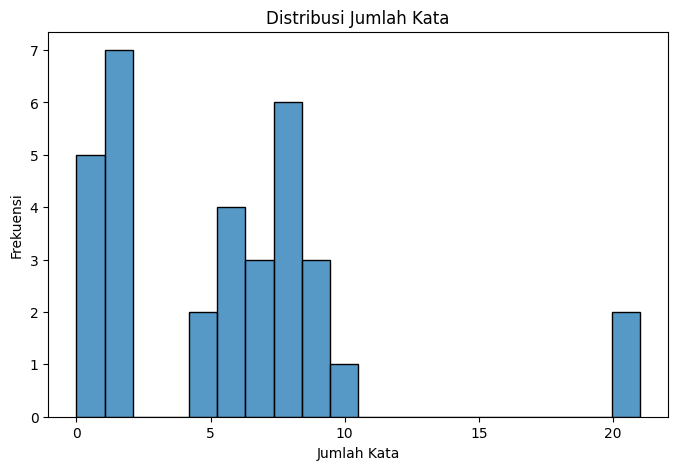

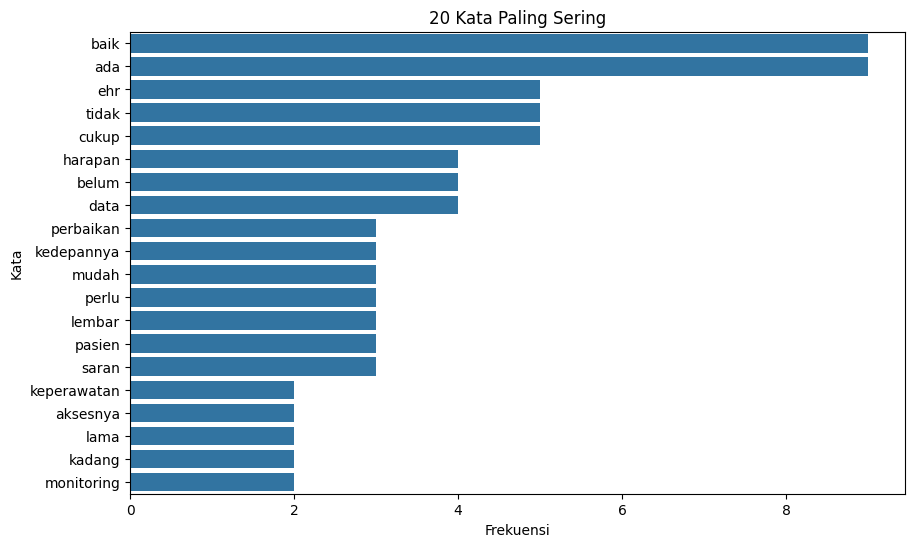

In [ ]:
# =========================
# JUMLAH KATA
# =========================

data['word_count'] = data['clean_text'].apply(lambda x: len(x.split()))
# Statistik jumlah kata

data['word_count'].describe()
# =========================
# DISTRIBUSI PANJANG TEKS
# =========================

plt.figure(figsize=(8,5))

sns.histplot(data['word_count'], bins=20)

plt.title('Distribusi Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

plt.show()
# =========================
# GABUNGKAN SEMUA TEKS
# =========================

all_text = ' '.join(data['clean_text'])
# =========================
# FREKUENSI KATA
# =========================

from collections import Counter

words = all_text.split()

word_freq = Counter(words)

# 20 kata paling sering
top_words = word_freq.most_common(20)

top_words
# =========================
# DATAFRAME TOP WORDS
# =========================

top_words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])

# =========================
# VISUALISASI TOP WORDS
# =========================

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word'
)

plt.title('20 Kata Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.show()

In [ ]:
top_words_df[['word', 'frequency']].head(15)

,word,frequency
0,baik,9
1,ada,9
2,ehr,5
3,tidak,5
4,cukup,5
5,harapan,4
6,belum,4
7,data,4
8,perbaikan,3
9,kedepannya,3


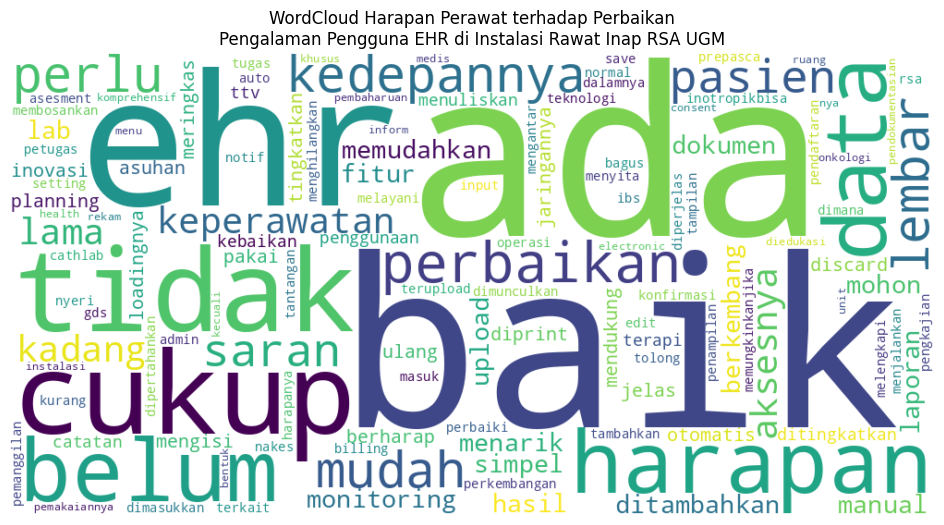

In [ ]:
# =========================
# WORDCLOUD
# =========================

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('WordCloud Harapan Perawat terhadap Perbaikan\n'
    'Pengalaman Pengguna EHR di Instalasi Rawat Inap RSA UGM')

plt.show()

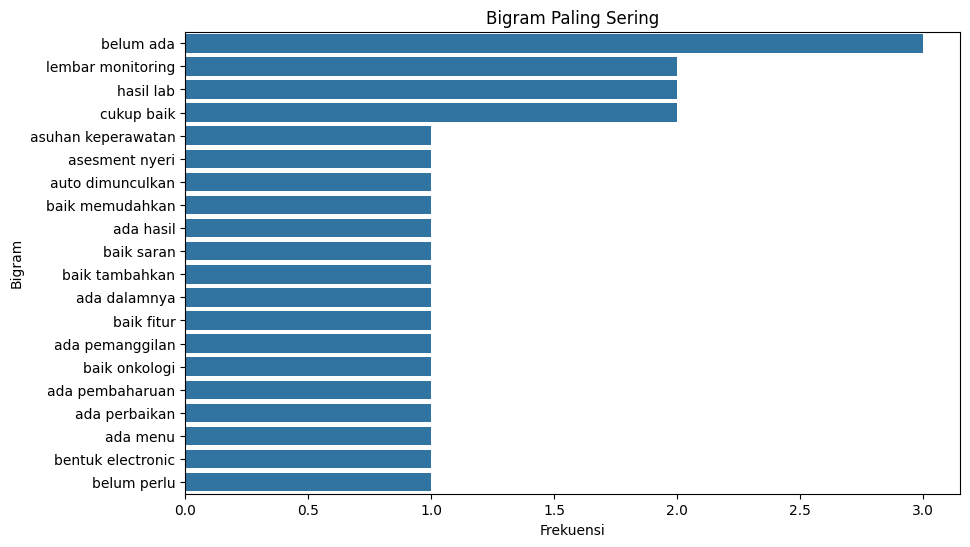

,bigram,frequency
0,belum ada,3
1,lembar monitoring,2
2,hasil lab,2
3,cukup baik,2
4,asuhan keperawatan,1
5,asesment nyeri,1
6,auto dimunculkan,1
7,baik memudahkan,1
8,ada hasil,1
9,baik saran,1


In [ ]:
# =========================
# BIGRAM
# =========================

from sklearn.feature_extraction.text import CountVectorizer
# =========================
# BIGRAM ANALYSIS
# =========================

bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['clean_text'])

bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_freq

# =========================
# VISUALISASI BIGRAM
# =========================

bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['bigram', 'frequency']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title('Bigram Paling Sering')

plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

bigram_df[['bigram', 'frequency']].head(33)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    # Jumlah maksimal feature
    max_features=1000,

    # Gunakan unigram + bigram
    ngram_range=(1,2),

    # Minimal muncul di 1 dokumen
    min_df=1,

    # Maksimal muncul di 90% dokumen
    max_df=0.9
)
# =========================
# TF-IDF TRANSFORMATION
# =========================

X = tfidf.fit_transform(
    data['clean_text']
)
# =========================
# SHAPE MATRIX
# =========================

print(X.shape)
# =========================
# FEATURE NAMES
# =========================

feature_names = tfidf.get_feature_names_out()

print(feature_names)

(33, 291)
['ada' 'ada dalamnya' 'ada hasil' 'ada menu' 'ada notif' 'ada pemanggilan'
 'ada pembaharuan' 'ada perbaikan' 'admin' 'aksesnya' 'aksesnya mudah'
 'asesment' 'asesment nyeri' 'asuhan' 'asuhan keperawatan' 'auto'
 'auto dimunculkan' 'bagus' 'baik' 'baik fitur' 'baik memudahkan'
 'baik onkologi' 'baik saran' 'baik tambahkan' 'belum' 'belum ada'
 'belum perlu' 'bentuk' 'bentuk electronic' 'berharap' 'berharap ehr'
 'berkembang' 'berkembang memudahkan' 'billing' 'billing auto' 'catatan'
 'catatan menuliskan' 'cathlab' 'cathlab mohon' 'consent' 'consent bentuk'
 'cukup' 'cukup baik' 'cukup tolong' 'dalamnya' 'data' 'data data'
 'data input' 'data laporan' 'data terkait' 'diedukasi' 'diedukasi unit'
 'dimana' 'dimana kadang' 'dimasukkan' 'dimasukkan ehr' 'dimunculkan'
 'dimunculkan konfirmasi' 'diperjelas' 'diperjelas mudah' 'dipertahankan'
 'dipertahankan baik' 'diprint' 'diprint tidak' 'discard'
 'discard planning' 'ditambahkan' 'ditambahkan catatan'
 'ditambahkan lembar' 'diting

In [ ]:
# =========================
# TF-IDF DATAFRAME
# =========================

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

tfidf_df.head()

,ada,ada dalamnya,ada hasil,ada menu,ada notif,ada pemanggilan,ada pembaharuan,ada perbaikan,admin,aksesnya,...,ttv,ttv ditambahkan,tugas,tugas tantangan,ulang,unit,unit pemakaiannya,upload,upload dokumen,upload menghilangkan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.543152,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.262532,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
# =========================
# RATA-RATA TF-IDF
# =========================

mean_tfidf = tfidf_df.mean().sort_values(
    ascending=False
)

print(mean_tfidf.head(15))

cukup              0.100429
baik               0.093983
ada                0.067414
belum              0.050751
belum ada          0.045582
cukup baik         0.042253
tidak              0.035542
ehr                0.029021
harapan            0.026259
data               0.023584
kedepannya         0.023249
perlu              0.022602
perbaikan          0.021644
penampilan         0.019824
penampilan baik    0.019824
dtype: float64


                                             response  \
0   Iya, saya berharap SIMRS terus melakukan inova...   
1   Iya, harapan yg jelas aksesnya mudah tidak lol...   
2   Ya, supaya bisa meringkas otomatis saat discar...   
3                                         sudah cukup   
4   bagian jaringannya saja mungkin perlu di tingk...   
5       Bisa ditingkatkan terus demi kebaikan bersama   
6   untuk lembar monitoring ttv bisa ditambahkan c...   
7   Semoga kedepannya lebih baik dan memudahkan pa...   
8                                   Tidak sudah bagus   
9                                                Bisa   
10  harapannya , tampilannya semakin menarik dan s...   
11                                         Sudah baik   
12  Ya , saya harap simrs terus berkembang dan sem...   
13  jika memungkinkan,jika ada hasil lab baru ada ...   
14                                              Cukup   
15  Iyaa perlu agar bisa lebih baik lagi, \nSaran ...   
16  ya, untuk pendaftaran cathl

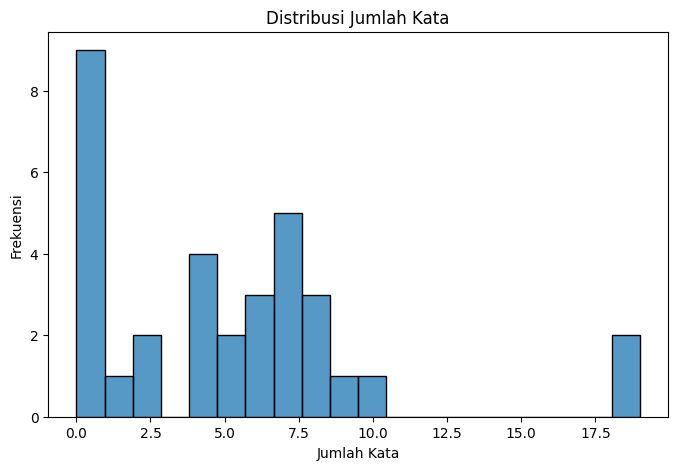

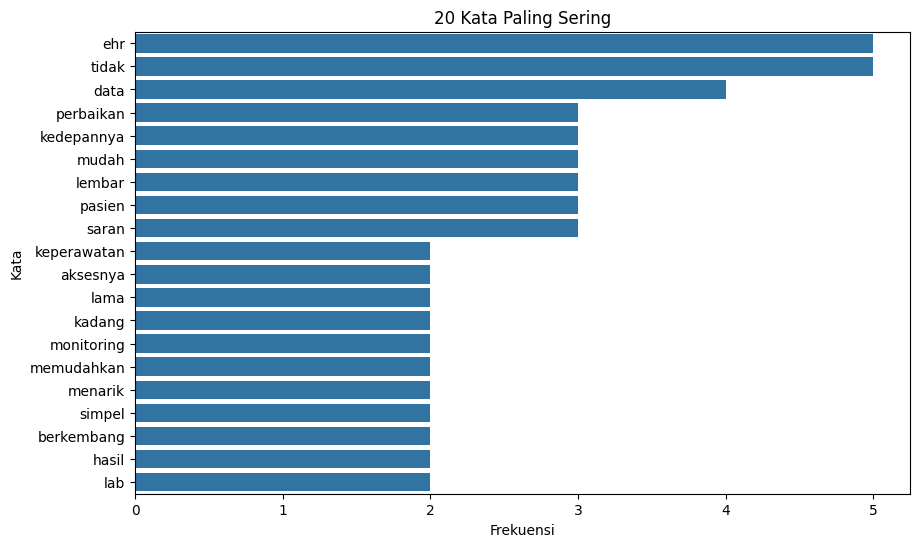

In [ ]:
# ============================================
# IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# ============================================
# STOPWORDS BAHASA INDONESIA
# ============================================

stop_words = stopwords.words('indonesian')

# ============================================
# KATA PENTING YANG DIPERTAHANKAN
# ============================================
# Kata-kata ini tetap dipertahankan karena
# berkaitan dengan:
# - UX
# - performa sistem
# - usability
# - workflow perawat
# - fitur EHR

important_words = [

    # Negasi
    'tidak',
    'kurang',

    # Performa sistem
    'lama',
    'loading',
    'lambat',
    'lemot',
    'error',
    'gangguan',

    # Usability / UX
    'mudah',
    'sulit',
    'rumit',
    'jelas',
    'simpel',
    'menarik',

    # Infrastruktur
    'internet',
    'jaringan',

    # Domain kesehatan / EHR
    'ehr',
    'pasien',
    'perawat',
    'lab',
    'billing',
    'dokumen',
    'monitoring',
    'pengkajian',
    'pendokumentasian',
    'fitur',
    'notif',
]

# ============================================
# ADDITIONAL STOPWORDS
# ============================================
# Kata-kata berikut dihapus karena:
# - terlalu umum
# - tidak memberi insight UX spesifik
# - hanya menunjukkan afirmasi/sentimen umum

additional_stopwords = [

    # Afirmasi
    'iya',
    'ya',
    'iyaa',

    # Sentimen umum
    'baik',
    'bagus',
    'cukup',
    'lebih',
    'bisa',

    # Kata umum
    'sudah',
    'semoga',
    'harap',
    'harapannya',
    'mungkin',
    'untuk',
    'saat',

    # Tidak memberi insight UX
    'ada',
    'perlu',
]

# ============================================
# REMOVE IMPORTANT WORDS DARI STOPWORDS
# ============================================

stop_words = [
    word for word in stop_words
    if word not in important_words
]

# Tambahkan additional stopwords
stop_words.extend(additional_stopwords)

# ============================================
# NORMALIZATION DICTIONARY
# ============================================

normalization_dict = {

    # Negasi
    'gak': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'tdk': 'tidak',

    # Kata umum
    'jg': 'juga',
    'tp': 'tetapi',
    'yg': 'yang',
    'udh': 'sudah',
    'sdh': 'sudah',
    'bgt': 'banget',
    'krn': 'karena',
    'dr': 'dari',
    'dgn': 'dengan',
    'trs': 'terus',

    # Domain UX / kesehatan
    'lola': 'lama',
    'simrs': 'ehr',
    'rm': 'rekam medis',

    # Typo
    'gk': 'tidak',
    'sm': 'sama',
    'udah': 'sudah',
    'memudahan': 'memudahkan',
    'tingktkan': 'tingkatkan',
    'loadinya': 'loadingnya',
    'penggunakan': 'penggunaan',
    'tehnologi': 'teknologi',
    'dimasukan': 'dimasukkan',
    'teruploas': 'terupload',
    'tampilannya': 'tampilan',

    # Variasi kata
    'terkadang': 'kadang',
}

# ============================================
# FUNCTION PREPROCESSING
# ============================================

def preprocess_text(text):

    # ----------------------------------------
    # 1. Pastikan format string
    # ----------------------------------------

    text = str(text)

    # ----------------------------------------
    # 2. Lowercase
    # ----------------------------------------

    text = text.lower()

    # ----------------------------------------
    # 4. Remove angka
    # ----------------------------------------

    text = re.sub(r'\d+', '', text)

    # ----------------------------------------
    # 5. Remove punctuation
    # ----------------------------------------

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # ----------------------------------------
    # 6. Remove whitespace berlebih
    # ----------------------------------------

    text = text.strip()

    text = re.sub(r'\s+', ' ', text)

    # ----------------------------------------
    # 7. Tokenization
    # ----------------------------------------

    tokens = word_tokenize(text)

    # ----------------------------------------
    # 8. Normalization
    # ----------------------------------------

    normalized_tokens = []

    for word in tokens:

        if word in normalization_dict:

            normalized_tokens.append(
                normalization_dict[word]
            )

        else:

            normalized_tokens.append(word)

    # ----------------------------------------
    # 9. Stopword removal
    # ----------------------------------------

    filtered_tokens = []

    for word in normalized_tokens:

        # Hapus stopwords
        if word not in stop_words:

            # Hapus token terlalu pendek
            if len(word) > 2:

                filtered_tokens.append(word)

    # ----------------------------------------
    # 10. Gabungkan kembali token
    # ----------------------------------------

    final_text = ' '.join(filtered_tokens)

    return final_text

# ============================================
# APPLY PREPROCESSING
# ============================================

data['clean_text'] = data['response'].apply(
    preprocess_text
)

# ============================================
# HASIL PREPROCESSING
# ============================================

print(
    data[['response', 'clean_text']].head(33)
)

# =========================
# JUMLAH KATA
# =========================

data['word_count'] = data['clean_text'].apply(lambda x: len(x.split()))
# Statistik jumlah kata

data['word_count'].describe()
# =========================
# DISTRIBUSI PANJANG TEKS
# =========================

plt.figure(figsize=(8,5))

sns.histplot(data['word_count'], bins=20)

plt.title('Distribusi Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

plt.show()
# =========================
# GABUNGKAN SEMUA TEKS
# =========================

all_text = ' '.join(data['clean_text'])
# =========================
# FREKUENSI KATA
# =========================

from collections import Counter

words = all_text.split()

word_freq = Counter(words)

# 20 kata paling sering
top_words = word_freq.most_common(20)

top_words
# =========================
# DATAFRAME TOP WORDS
# =========================

top_words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])

# =========================
# VISUALISASI TOP WORDS
# =========================

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word'
)

plt.title('20 Kata Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.show()

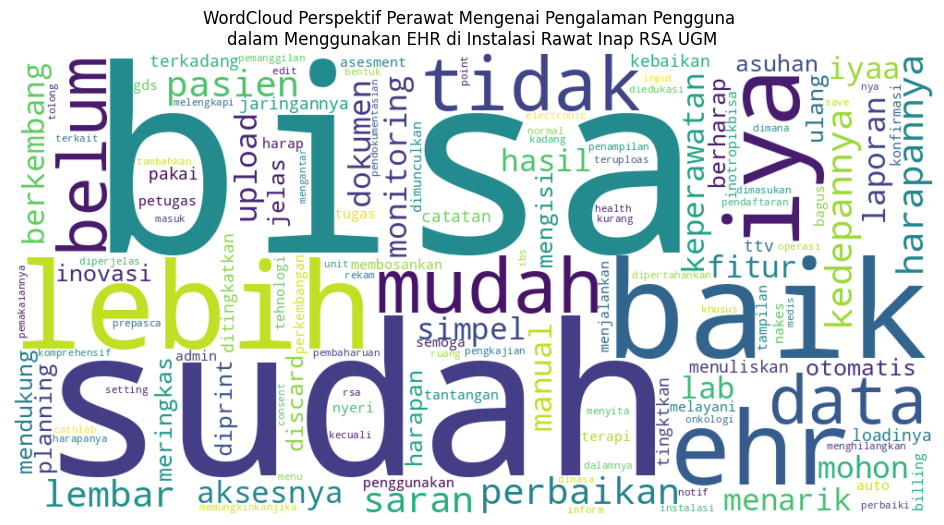

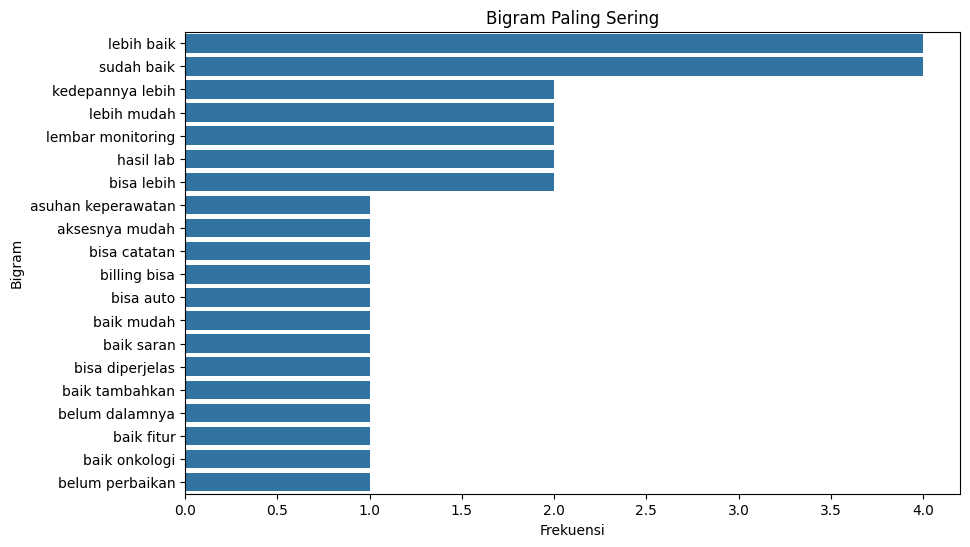

,bigram,frequency
0,lebih baik,4
1,sudah baik,4
2,kedepannya lebih,2
3,lebih mudah,2
4,lembar monitoring,2
5,hasil lab,2
6,bisa lebih,2
7,asuhan keperawatan,1
8,aksesnya mudah,1
9,bisa catatan,1


In [ ]:
# =========================
# BIGRAM
# =========================

from sklearn.feature_extraction.text import CountVectorizer
# =========================
# BIGRAM ANALYSIS
# =========================

bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['clean_text'])

bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_freq

# =========================
# VISUALISASI BIGRAM
# =========================

bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['bigram', 'frequency']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title('Bigram Paling Sering')

plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

bigram_df[['bigram', 'frequency']].head(33)

Analisis Kategorisasi

Jumlah data : 33
Nama kolom  : ['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda']

Jumlah respons valid : 33

Tabel Distribusi Jawaban
                       Kategori  Frekuensi  Persentase (%)
0        Mengharapkan Perbaikan         24            72.7
1  Tidak Mengharapkan Perbaikan          9            27.3


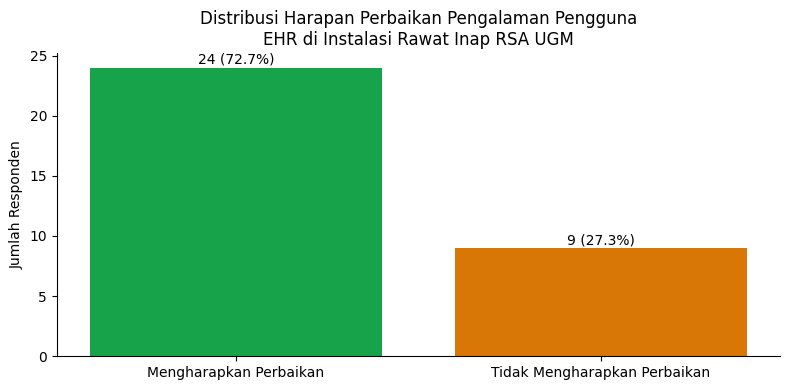

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import re

# WARNA VISUALISASI
COLOR_YES = '#16A34A'   # Hijau
COLOR_NO  = '#D97706'   # Orange

# Membaca file Excel
df_raw = pd.read_excel('Data Kualitatif Mengenai Harapan.xlsx')

# Menampilkan informasi dataset
print("Jumlah data :", len(df_raw))
print("Nama kolom  :", df_raw.columns.tolist())

# Menggunakan kolom pertama sebagai jawaban responden
response_column = df_raw.columns[0]

# Membuat dataframe baru
df = pd.DataFrame()

# Membersihkan data
df['response'] = (
    df_raw[response_column]
    .astype(str)
    .str.strip()
)

# Menghapus jawaban kosong
df = df[df['response'].str.len() > 1]

# Reset index
df = df.reset_index(drop=True)

print("\nJumlah respons valid :", len(df))

# Mengubah singkatan menjadi kata lengkap
normalization_dict = {
    r'\byg\b'   : 'yang',
    r'\butk\b'  : 'untuk',
    r'\bdgn\b'  : 'dengan',
    r'\btdk\b'  : 'tidak',
    r'\bkrn\b'  : 'karena',
    r'\bblm\b'  : 'belum',
    r'\bsdh\b'  : 'sudah',
    r'\bdr\b'   : 'dari',
}

def normalize_text(text):

    text = text.lower()

    for pattern, replacement in normalization_dict.items():
        text = re.sub(pattern, replacement, text)

    return text

# Kata kunci yang menunjukkan TIDAK mengharapkan perbaikan
no_patterns = [
    'sudah cukup',
    'cukup baik',
    'sudah baik',
    'sudah bagus',
    'belum perlu',
    'tidak ada kendala',
    'sejauh ini belum',
]

# Kata kunci yang menunjukkan MENGHARAPKAN perbaikan
yes_patterns = [
    r'\biya\b',
    r'\bya\b',
    r'\bharap\b',
    r'\bsaran\b',
    r'\bperbaikan\b',
    r'\bdiperbaiki\b',
    r'\bditingkatkan\b',
    r'\bditambahkan\b',
    r'\bsemoga\b',
]

# Fungsi kategorisasi
def categorize_response(text):

    text = normalize_text(text)

    # Cek kategori tidak mengharapkan perbaikan
    for pattern in no_patterns:
        if pattern in text:
            return 'Tidak Mengharapkan Perbaikan'

    # Cek kategori mengharapkan perbaikan
    for pattern in yes_patterns:
        if re.search(pattern, text):
            return 'Mengharapkan Perbaikan'

    # Jika tidak masuk keduanya,
    # otomatis dianggap mengharapkan perbaikan
    return 'Mengharapkan Perbaikan'

# Menerapkan kategorisasi
df['category'] = df['response'].apply(categorize_response)

# Menghitung frekuensi
frequency_table = df['category'].value_counts().reset_index()

# Mengubah nama kolom
frequency_table.columns = ['Kategori', 'Frekuensi']

# Menghitung persentase
frequency_table['Persentase (%)'] = (
    frequency_table['Frekuensi'] / len(df) * 100
).round(1)

# Menampilkan tabel
print("\nTabel Distribusi Jawaban")
print(frequency_table)

# Menentukan warna diagram
colors = [
    COLOR_YES if category == 'Mengharapkan Perbaikan'
    else COLOR_NO
    for category in frequency_table['Kategori']
]

# Membuat figure
plt.figure(figsize=(8, 4))

# Membuat bar chart
bars = plt.bar(
    frequency_table['Kategori'],
    frequency_table['Frekuensi'],
    color=colors
)

# Menambahkan label jumlah dan persentase
for i, bar in enumerate(bars):

    freq = frequency_table['Frekuensi'][i]
    pct  = frequency_table['Persentase (%)'][i]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{freq} ({pct}%)',
        ha='center',
        fontsize=10
    )

# Judul dan label
plt.title(
    'Distribusi Harapan Perbaikan Pengalaman Pengguna\n'
    'EHR di Instalasi Rawat Inap RSA UGM'
)

plt.ylabel('Jumlah Responden')

# Menghapus garis atas dan kanan
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Menampilkan visualisasi
plt.tight_layout()

plt.show()

Dimensi dataset : 33 baris × 1 kolom
Nama kolom      : ['Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda']
Jumlah respons valid : 33
Hasil kategorisasi:
category
Mengharapkan Perbaikan          22
Tidak Mengharapkan Perbaikan    11
DISTRIBUSI KATEGORISASI AKHIR
  Mengharapkan Perbaikan                  : 22 responden (66.7%)
  Tidak Mengharapkan Perbaikan            : 11 responden (33.3%)
  Total                                   : 33 responden (100.0%)


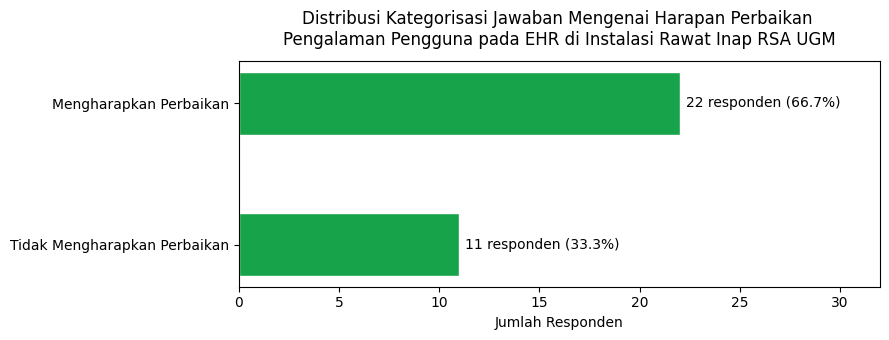

✓ Tersimpan: 01_distribusi_kategorisasi.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import re
import string
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

COLOR_PRIMARY = '#1D4ED8'
COLOR_YES     = '#16A34A'
COLOR_NO      = '#D97706'
COLOR_AMBIG   = '#D97706'

# =========================
# LOAD DATASET
# =========================

# Load file Excel
df_raw = pd.read_excel('Data Kualitatif Mengenai Harapan.xlsx')

# Melihat 5 data pertama
print(f"Dimensi dataset : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")
print(f"Nama kolom      : {df_raw.columns.tolist()}")
df_raw.head()


# =========================
# IDENTIFIKASI KOLOM RESPONS
# =========================

response_column = df_raw.columns[0]

df = pd.DataFrame()
df['response'] = df_raw[response_column].astype(str).str.strip()
df['id']       = range(1, len(df) + 1)

# Hapus baris kosong atau tidak relevan
df = df[df['response'].str.len() > 1].reset_index(drop=True)
df['id'] = range(1, len(df) + 1)

print(f"Jumlah respons valid : {len(df)}")
df.head(10)


# ## 3. Kategorisasi Jawaban
# Pendekatan: **rule-based keyword** sebagai langkah otomatis pertama,
# dilanjutkan **manual review dan override** oleh peneliti.
# Setiap override didokumentasikan secara eksplisit.


# =========================
# NORMALISASI SINGKATAN
# =========================
normalization_dict = {
    r'\byg\b'    : 'yang',
    r'\butk\b'   : 'untuk',
    r'\bdgn\b'   : 'dengan',
    r'\bdg\b'    : 'dengan',
    r'\bdr\b'    : 'dari',
    r'\bpd\b'    : 'pada',
    r'\bkrn\b'   : 'karena',
    r'\bkarna\b' : 'karena',
    r'\btdk\b'   : 'tidak',
    r'\btdak\b'  : 'tidak',
    r'\bbs\b'    : 'bisa',
    r'\bdll\b'   : '',
    r'\bdst\b'   : '',
    r'\btsb\b'   : 'tersebut',
    r'\bskrg\b'  : 'sekarang',
    r'\bsdh\b'   : 'sudah',
    r'\bblm\b'   : 'belum',
    r'\btingktkan\b'    : 'tingkatkan',
    r'\bharapanya\b'    : 'harapannya',
    r'\byg\b'    : 'yang',
}

def normalize_abbreviations(text):
    text = str(text).lower()
    for pattern, replacement in normalization_dict.items():
        text = re.sub(pattern, replacement, text)
    return text

# =========================
# RULE-BASED KATEGORISASI
# =========================

# Pola ekspresi kepuasan eksplisit → Tidak Mengharapkan Perbaikan
no_patterns = [
    'sudah cukup', 'cukup', 'cukup baik', 'sudah baik', 'sudah bagus',
    'belum perlu', 'belum ada', 'tidak sudah', 'on point',
    'simpel dan menarik', 'untuk saat ini belum', 'sejauh ini belum',
]

# Pola harapan atau saran perbaikan → Mengharapkan Perbaikan
yes_patterns = [
    r'\biya\b', r'\biyaa\b', r'^\s*ya[\s,]', r'\bharap\b', r'\bbisa\b',
    r'\bharapan\b', r'\bharapannya\b', r'\bsaran\b', r'\bperbaikan\b',
    r'\bdiperbaiki\b', r'\bmemungkinkan\b',
    r'\bditingkatkan\b', r'\btingkatkan\b', r'\bditambahkan\b',
    r'\btambahkan\b', r'\bsemoga\b',
]

def rule_based_categorize(text):
    t = normalize_abbreviations(text)

    # Cek pola kepuasan terlebih dahulu
    for pat in no_patterns:
        if pat in t:
            return 'Tidak Mengharapkan Perbaikan'

    # Cek pola harapan perbaikan
    for pat in yes_patterns:
        if re.search(pat, t):
            return 'Mengharapkan Perbaikan'

    return 'Ambigu'

df['category'] = df['response'].apply(rule_based_categorize)

print("Hasil kategorisasi:")
print(df['category'].value_counts().to_string())
df[['id', 'response', 'category']].head(10)


# =========================
# MANUAL REVIEW & OVERRIDE
# =========================
# Tinjau baris dengan kategori 'Ambigu' dan tentukan kategori akhirnya.
# Dokumentasikan setiap keputusan override di sini.

#print("Baris dengan kategori Ambigu:")
#print(df[df['category'] == 'Ambigu'][['id', 'response']].to_string(index=False))


# %%
# -------------------------------------------------------------------
# INSTRUKSI: Isi dictionary di bawah dengan pasangan
#            {id_responden : ('Kategori Baru', 'Alasan Override')}
#
# Contoh override berdasarkan data asli penelitian ini:
#   - Responden #10 menjawab "Bisa" → diinterpretasikan sebagai
#     "Bisa ditingkatkan" dalam konteks pertanyaan harapan perbaikan
#   - Responden #18 menjawab "Sudah cukup dan minta tolong
#     dipertahankan, jika lebih baik di tambahkan..." → mengandung
#     saran konkret meski diawali ekspresi kepuasan
#   - Responden #25 menjawab "Bisa" → sama dengan #10
#
# Sesuaikan nomor ID dengan hasil df yang Anda miliki.
# -------------------------------------------------------------------

# MANUAL_OVERRIDES = {
#     10 : ('Mengharapkan Perbaikan', '"Bisa" = "Bisa ditingkatkan"'),
#     15 : ('Mengharapkan Perbaikan', '"Cukup" dalam konteks ini memiliki arti tidak mengharapkan perbaikan'),
#     21 : ('Mengharapkan Perbaikan', '"Bisa" = "Bisa ditingkatkan"'),
#}

# Terapkan override
#for resp_id, (new_cat, reason) in MANUAL_OVERRIDES.items():
#    mask = df['id'] == resp_id
#    df.loc[mask, 'category'] = new_cat
#    print(f"Override Responden #{resp_id}: '{new_cat}' — {reason}")

#if not MANUAL_OVERRIDES:
#    print("Tidak ada override yang diterapkan. Tinjau baris Ambigu di atas,")
#    print("lalu isi MANUAL_OVERRIDES jika diperlukan.")



# =========================
# DISTRIBUSI KATEGORISASI
# =========================
dist = df['category'].value_counts()


print("DISTRIBUSI KATEGORISASI AKHIR")
for cat, cnt in dist.items():
    pct = cnt / len(df) * 100
    print(f"  {cat:<40}: {cnt:>2} responden ({pct:.1f}%)")
print(f"  {'Total':<40}: {len(df):>2} responden (100.0%)")

# Visualisasi
cat_colors = [
    COLOR_YES   if 'Mengharapkan' in c else
    COLOR_NO    if 'Tidak'         in c else
    COLOR_AMBIGU
    for c in dist.index
]

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(dist.index, dist.values,
               color=cat_colors, height=0.45, edgecolor='white')
for bar, val in zip(bars, dist.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val} responden ({pct:.1f}%)',
            va='center', ha='left', fontsize=10)
ax.set_xlim(0, max(dist.values) + 10)
ax.set_xlabel('Jumlah Responden')
ax.set_title(
    'Distribusi Kategorisasi Jawaban Mengenai Harapan Perbaikan \nPengalaman Pengguna pada EHR di Instalasi Rawat Inap RSA UGM',
    pad=12
)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('01_distribusi_kategorisasi.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Tersimpan: 01_distribusi_kategorisasi.png")

In [ ]:
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    _factory         = StemmerFactory()
    _stemmer         = _factory.createStemmer()
    _sw_factory      = StopWordRemoverFactory()
    SASTRAWI_SW      = set(_sw_factory.get_stop_words())
    SASTRAWI_AVAILABLE = True
    print("✓ PySastrawi tersedia — stemming aktif")
except ImportError:
    SASTRAWI_AVAILABLE = False
    SASTRAWI_SW        = set()
    print("✗ PySastrawi tidak tersedia — jalankan: !pip install PySastrawi")

    ADDITIONAL_STOPWORDS = {
    # Kata ganti
    'saya', 'kami', 'kita', 'anda', 'dia', 'mereka',
    # Kata depan & sambung
    'ini', 'itu', 'ke', 'di', 'dari', 'dan', 'yang', 'untuk', 'dengan',
    'pada', 'atau', 'juga', 'dalam', 'oleh', 'ada', 'akan', 'telah',
    'adalah', 'karena', 'jika', 'kalau', 'agar', 'supaya', 'maka',
    'sehingga', 'tapi', 'tetapi', 'namun', 'walaupun', 'meski',
    'ketika', 'saat', 'setelah', 'sebelum', 'selama', 'sejak',
    'antara', 'tanpa', 'terhadap', 'tentang', 'sebagai', 'seperti',
    'pun', 'lah', 'kah', 'demi', 'atas', 'bawah',
    # Kata keterangan umum
    'sangat', 'paling', 'semakin', 'terlalu', 'agak', 'hampir',
    'sekitar', 'sampai', 'hingga', 'hanya', 'saja', 'bahkan',
    'selain', 'jadi', 'memang', 'terus', 'kembali', 'lagi', 'masih',
    'pernah', 'sedang', 'makin', 'lain',
    # Kata modal / kata bantu
    'harus', 'boleh', 'dapat', 'bisa', 'mau', 'ingin', 'hendak',
    'sudah', 'belum', 'tidak', 'tak', 'bukan', 'jangan',
    # Kata informal / singkatan
    'yg', 'utk', 'dgn', 'dg', 'dr', 'pd', 'krn', 'karna',
    'tdk', 'bs', 'dll', 'dst', 'tsb', 'skrg', 'sdh', 'blm',
    'iya', 'ya', 'iyaa', 'udah', 'udh', 'aja', 'kayak',
    # Entitas nama (analisis fokus pada konten substantif)
    'ehr', 'simrs', 'rsa', 'ugm',
    # Kata terlalu umum dalam korpus ini
    'mohon', 'tolong', 'silakan', 'mungkin', 'perlu',
    'setiap', 'semua', 'beberapa', 'banyak', 'sedikit',
    'cara', 'tempat', 'waktu', 'hal', 'sama',
    # Kata sapaan / penutup
    'para', 'nakes',
}

ALL_STOPWORDS = SASTRAWI_SW | ADDITIONAL_STOPWORDS

print(f"Total stopword   : {len(ALL_STOPWORDS)}")
print(f"  Sastrawi       : {len(SASTRAWI_SW)}")
print(f"  Tambahan       : {len(ADDITIONAL_STOPWORDS)}")


# %%
# =========================
# FUNGSI PREPROCESSING
# =========================
def preprocess(text):
    """
    Mengembalikan list token bersih.
    Langkah:
      1. Normalisasi singkatan
      2. Lowercase
      3. Hapus karakter non-alfabet
      4. Tokenisasi (split by whitespace)
      5. Hapus stopword
      6. Stemming dengan Sastrawi (jika tersedia)
      7. Hapus token terlalu pendek (≤ 2 karakter)
    """
    # 1 & 2. Normalisasi + lowercase
    text = normalize_abbreviations(text)
    # 3. Hapus karakter non-alfabet
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. Tokenisasi
    tokens = text.split()
    # 5. Hapus stopword
    tokens = [t for t in tokens if t not in ALL_STOPWORDS]
    # 6. Stemming
    if SASTRAWI_AVAILABLE:
        tokens = [_stemmer.stem(t) for t in tokens]
    # 7. Hapus token pendek
    tokens = [t for t in tokens if len(t) > 2]
    return tokens

df['tokens']     = df['response'].apply(preprocess)
df['text_clean'] = df['tokens'].apply(lambda x: ' '.join(x))

# Tampilkan contoh hasil
print("Contoh hasil preprocessing:\n")
for _, row in df.head(33).iterrows():
    print(f"  #{row['id']} [{row['category']}]")
    print(f"  Asli   : {row['response'][:90]}")
    print(f"  Bersih : {row['text_clean'][:90]}")
    print()

✗ PySastrawi tidak tersedia — jalankan: !pip install PySastrawi
Total stopword   : 134
  Sastrawi       : 0
  Tambahan       : 134
Contoh hasil preprocessing:

  #1 [Mengharapkan Perbaikan]
  Asli   : Iya, saya berharap SIMRS terus melakukan inovasi perbaikan kedepannya agar lebih mudah dan
  Bersih : berharap melakukan inovasi perbaikan kedepannya lebih mudah mendukung asuhan keperawatan m

  #2 [Mengharapkan Perbaikan]
  Asli   : Iya, harapan yg jelas aksesnya mudah tidak lola aksesnya
  Bersih : harapan jelas aksesnya mudah lola aksesnya

  #3 [Mengharapkan Perbaikan]
  Asli   : Ya, supaya bisa meringkas otomatis saat discard planning mau diprint supaya tidak mengisi 
  Bersih : meringkas otomatis discard planning diprint mengisi ulang

  #4 [Tidak Mengharapkan Perbaikan]
  Asli   : sudah cukup
  Bersih : cukup

  #5 [Mengharapkan Perbaikan]
  Asli   : bagian jaringannya saja mungkin perlu di tingktkan, terkadang sangat lama loadinya jika di
  Bersih : bagian jaringannya tingkatkan 

STATISTIK DESKRIPTIF RESPONS
              Jumlah Karakter  Jumlah Kata (Sebelum Preprocessing)  Jumlah Token (Setelah Preprocessing)
Jumlah                  33.00                                33.00                                 33.00
Rata-rata               77.24                                11.58                                  6.24
Std. Deviasi            65.59                                 9.57                                  5.54
Minimum                  4.00                                 1.00                                  0.00
Q1 (25%)                24.00                                 5.00                                  2.00
Median (50%)            73.00                                10.00                                  5.00
Q3 (75%)                98.00                                16.00                                  8.00
Maksimum               288.00                                47.00                                 22.00


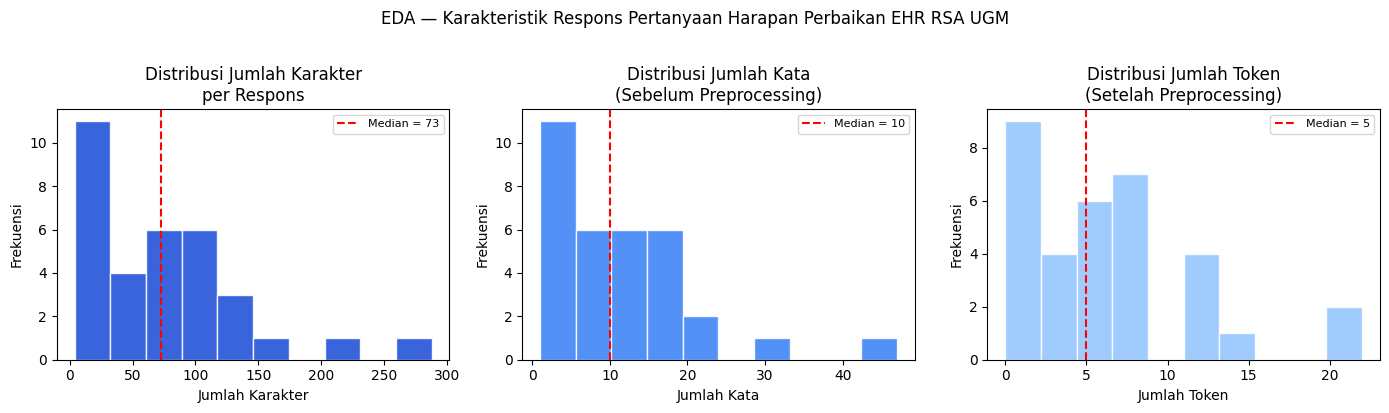

✓ Tersimpan: 02_eda_distribusi.png
Total token unik : 151
Total token      : 206

                  Kata  Frekuensi
Peringkat                        
1                 baik          9
2                lebih          7
3                cukup          5
4           harapannya          4
5                 data          4
6            perbaikan          3
7           kedepannya          3
8                mudah          3
9               bagian          3
10              lembar          3
11              pasien          3
12                baru          3
13               saran          3
14         keperawatan          2
15            aksesnya          2
16          monitoring          2
17         ditambahkan          2
18          memudahkan          2
19             menarik          2
20              simpel          2
21          berkembang          2
22               hasil          2
23                 lab          2
24              manual          2
25              upload          2


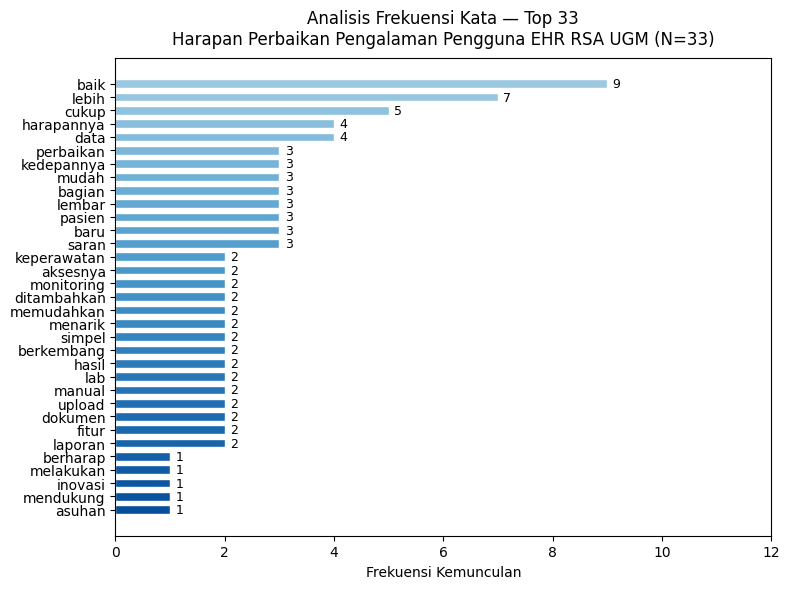

✓ Tersimpan: 03_word_frequency.png


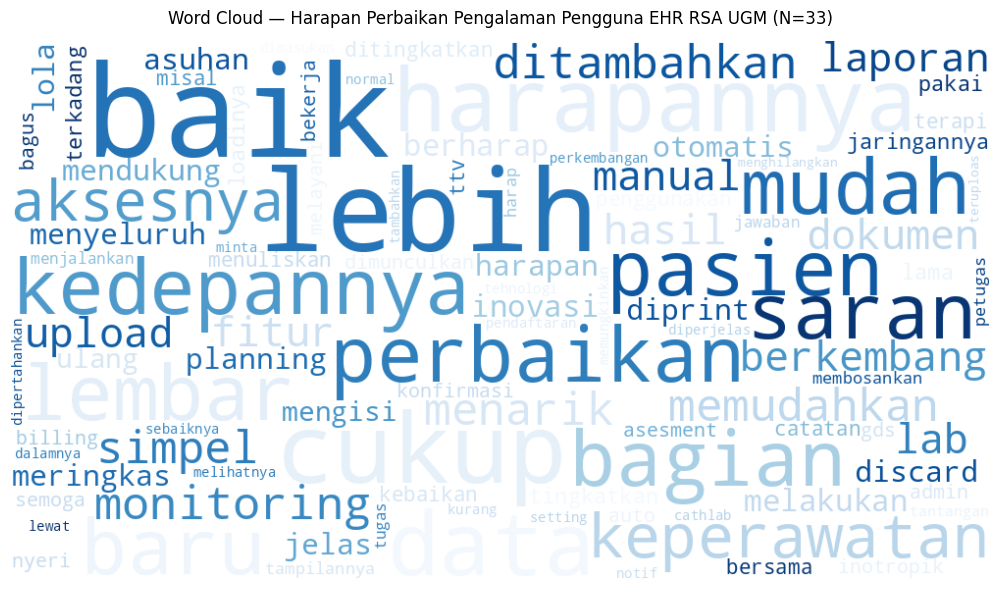

✓ Tersimpan: 04_wordcloud.png
Total bigram unik : 168

                           Bigram  Frekuensi
Peringkat                                   
1                      lebih baik          4
2                kedepannya lebih          2
3                     lebih mudah          2
4               lembar monitoring          2
5                       hasil lab          2
6                      cukup baik          2
7              berharap melakukan          1
8               melakukan inovasi          1
9               inovasi perbaikan          1
10           perbaikan kedepannya          1
11                mudah mendukung          1
12               mendukung asuhan          1
13             asuhan keperawatan          1
14         keperawatan menyeluruh          1
15                  harapan jelas          1
16                 jelas aksesnya          1
17                 aksesnya mudah          1
18                     mudah lola          1
19                  lola aksesnya          1


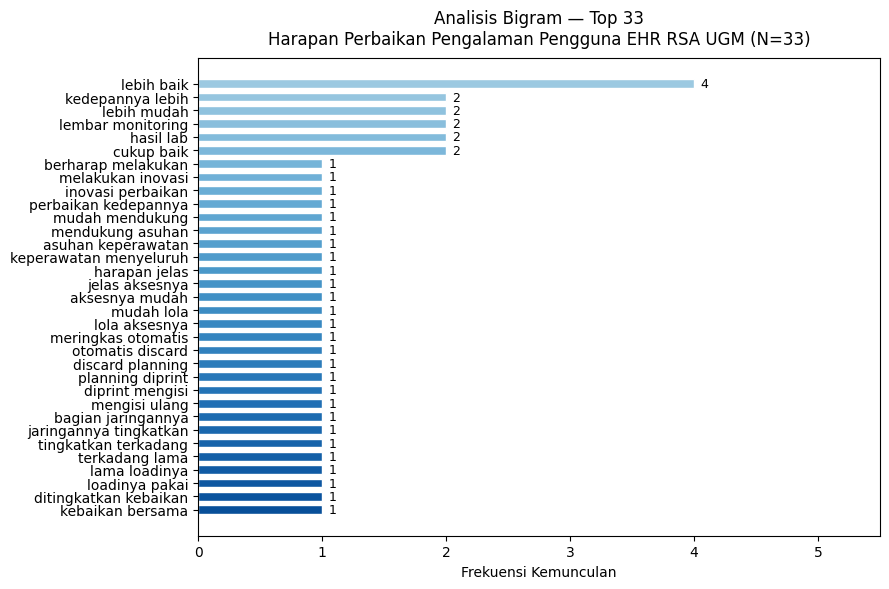

✓ Tersimpan: 05_bigram.png


In [ ]:
# =========================
# VISUALISASI EDA
# =========================

# Pastikan kolom tersedia sebelum visualisasi
# (akan dihitung ulang jika belum ada di DataFrame)
df['char_count']  = df['response'].apply(len)
df['word_raw']    = df['response'].apply(lambda x: len(x.split()))
df['token_count'] = df['tokens'].apply(len)

# Statistik deskriptif
stats = df[['char_count', 'word_raw', 'token_count']].describe()
stats.index  = ['Jumlah', 'Rata-rata', 'Std. Deviasi', 'Minimum',
                'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Maksimum']
stats.columns = ['Jumlah Karakter',
                 'Jumlah Kata (Sebelum Preprocessing)',
                 'Jumlah Token (Setelah Preprocessing)']
print("STATISTIK DESKRIPTIF RESPONS")
print(stats.round(2).to_string())

# Visualisasi
col_cfg = [
    ('char_count',  'Jumlah Karakter',
     'Distribusi Jumlah Karakter\nper Respons',            '#1D4ED8'),
    ('word_raw',    'Jumlah Kata',
     'Distribusi Jumlah Kata\n(Sebelum Preprocessing)',    '#3B82F6'),
    ('token_count', 'Jumlah Token',
     'Distribusi Jumlah Token\n(Setelah Preprocessing)',   '#93C5FD'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, xlabel, title, color) in zip(axes, col_cfg):
    ax.hist(df[col], bins=10, color=color,
            edgecolor='white', alpha=0.88)
    median_val = df[col].median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Median = {median_val:.0f}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

plt.suptitle(
    'EDA — Karakteristik Respons Pertanyaan Harapan Perbaikan EHR RSA UGM',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('02_eda_distribusi.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Tersimpan: 02_eda_distribusi.png")


# ## 6. Analisis Frekuensi Kata


# %%
# =========================
# WORD FREQUENCY
# =========================
all_tokens = [tok for toks in df['tokens'] for tok in toks]
word_freq  = Counter(all_tokens)
top_words  = word_freq.most_common(33)

# Tampilkan tabel
wf_table = pd.DataFrame(top_words, columns=['Kata', 'Frekuensi'])
wf_table.index = range(1, len(wf_table) + 1)
wf_table.index.name = 'Peringkat'

print(f"Total token unik : {len(word_freq)}")
print(f"Total token      : {len(all_tokens)}\n")
print(wf_table.to_string())
wf_table


# %%
# =========================
# VISUALISASI FREKUENSI KATA
# =========================
words_list = [w for w, _ in top_words]
freqs_list = [f for _, f in top_words]

fig, ax = plt.subplots(figsize=(8, 6))
colors_w = plt.cm.Blues(np.linspace(0.38, 0.88, len(words_list)))[::-1]
bars = ax.barh(words_list[::-1], freqs_list[::-1],
               color=colors_w, edgecolor='white', height=0.65)
for bar, val in zip(bars, freqs_list[::-1]):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=9)
ax.set_xlabel('Frekuensi Kemunculan')
ax.set_xlim(0, max(freqs_list) + 3)
ax.set_title(
    f'Analisis Frekuensi Kata — Top {33}\n'
    'Harapan Perbaikan Pengalaman Pengguna EHR RSA UGM (N=33)',
    pad=10
)
plt.tight_layout()
plt.savefig('03_word_frequency.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Tersimpan: 03_word_frequency.png")


# ## 7. Word Cloud


# %%
# =========================
# WORD CLOUD
# =========================
text_for_wc = ' '.join(all_tokens)

wordcloud = WordCloud(
    width            = 1000,
    height           = 550,
    background_color = 'white',
    colormap         = 'Blues',
    max_words        = 100,
    min_font_size    = 10,
    max_font_size    = 130,
    prefer_horizontal= 0.85,
    collocations     = False,   # hindari duplikasi pasangan kata
    random_state     = 42,
).generate(text_for_wc)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Word Cloud — Harapan Perbaikan Pengalaman Pengguna EHR RSA UGM (N=33)',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig('04_wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Tersimpan: 04_wordcloud.png")


# ## 8. Analisis Bigram


# %%
# =========================
# BIGRAM ANALYSIS
# =========================
def extract_bigrams(token_list):
    """Ekstrak semua pasangan bigram berurutan dari list token."""
    if len(token_list) < 2:
        return []
    return [f"{token_list[i]} {token_list[i+1]}"
            for i in range(len(token_list) - 1)]

all_bigrams = [bg for toks in df['tokens']
               for bg in extract_bigrams(toks)]
bigram_freq = Counter(all_bigrams)
top_bigrams = bigram_freq.most_common(33)

# Tampilkan tabel
bg_table = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frekuensi'])
bg_table.index = range(1, len(bg_table) + 1)
bg_table.index.name = 'Peringkat'

print(f"Total bigram unik : {len(bigram_freq)}\n")
print(bg_table.to_string())
bg_table


# =========================
# VISUALISASI BIGRAM
# =========================
bg_labels = [bg for bg, _ in top_bigrams]
bg_values = [f  for _,  f in top_bigrams]

fig, ax = plt.subplots(figsize=(9, 6))
colors_bg = plt.cm.Blues(np.linspace(0.38, 0.88, len(bg_labels)))[::-1]
bars = ax.barh(bg_labels[::-1], bg_values[::-1],
               color=colors_bg, edgecolor='white', height=0.65)
for bar, val in zip(bars, bg_values[::-1]):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=9)
ax.set_xlabel('Frekuensi Kemunculan')
ax.set_xlim(0, max(bg_values) + 1.5)
ax.set_title(
    f'Analisis Bigram — Top 33\n'
    'Harapan Perbaikan Pengalaman Pengguna EHR RSA UGM (N=33)',
    pad=10
)
plt.tight_layout()
plt.savefig('05_bigram.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Tersimpan: 05_bigram.png")
